# Documentation of the method to detect interfaces
This notebook describes the method that is used to detect air-snow, snow-ice, and ice-water interfaces from the thermistor string-based temperature data. 

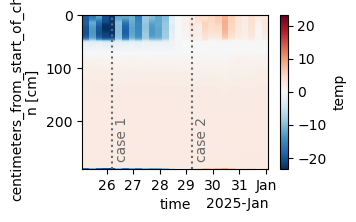

In [110]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cmocean.cm as cmo

data = xr.open_dataset("test_data.nc")
d1 = 4
d2 = 16
isurf = 25 # air/water interface before freezing, see documentation.ipynb for details

plt.figure(figsize=(3,2))
data.temp.plot(y="pos", yincrease=False)
plt.vlines(data.time.isel(time=d1), 290, 0, ls=":", color="dimgray")
plt.text(data.time.isel(time=d1)+int(1e13), 270, "case 1", rotation=90, color="dimgray")
plt.vlines(data.time.isel(time=d2), 290, 0, ls=":", color="dimgray")
plt.text(data.time.isel(time=d2)+int(1e13), 270, "case 2", rotation=90, color="dimgray");

## Air temperature < 0$^{\circ}$C

First consider a case where the air temperature is negative (case 1) in the figure above

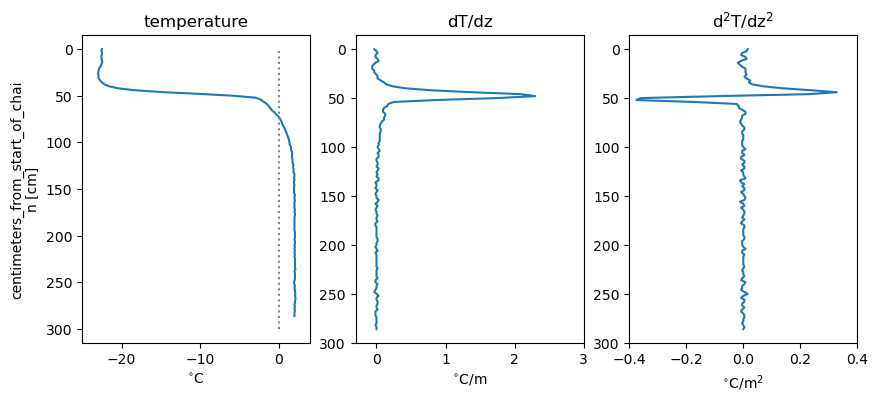

In [111]:
d = d1
da = data.isel(time=d, pos=slice(None, -1))

# get vertical gradients
dTdz = da.temp.differentiate("pos")
d2Tdz2 = dTdz.differentiate("pos")

# axes' limits for plotting
l0 = -25
u0 = 4
l1 = -0.3
u1 = 3
l2 = -0.4
u2 = 0.4

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False)
ax[0].vlines(0, 300, 0, ls=":", color="gray")
ax[0].set_xlim(l0, u0)
ax[0].set_title("temperature")
ax[0].set_xlabel("$^{\circ}$C")

dTdz.plot(ax=ax[1], y="pos", yincrease=False)
ax[1].set_xlim(l1, u1)
ax[1].set_title("dT/dz")
ax[1].set_xlabel("$^{\circ}$C/m")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False)
ax[2].set_xlim(l2, u2)
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("$^{\circ}$C/m$^{2}$")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")

The water/ice interface or bottom of the ice is detected by simply looking for the first occurence of a temperature below zero, starting from the bottom of the thermistor chain. It also has to be below the depth that was determined to be the air/water interface before the water started freezing (`isurf`).

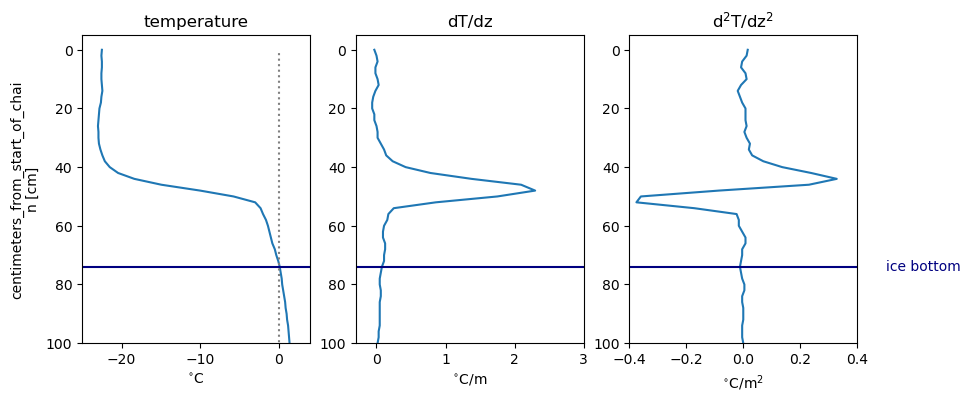

In [112]:
iiceBot = xr.where(da.temp < 0, True, False)[::-1].cumsum("pos")[::-1].argmin("pos") # index of ice bottom along dimension `pos` 
iceBot = da.pos[iiceBot].where(((iiceBot != 0) & (iiceBot >= isurf)), other=da.pos.isel(pos=isurf).values) # depth of ice bottom

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False)
ax[0].hlines(da.pos.isel(pos=iiceBot), l0, u0, color="navy", ls="-")
ax[0].vlines(0, 300, 0, ls=":", color="gray")
ax[0].set_xlim(l0, u0)
ax[0].set_title("temperature")
ax[0].set_xlabel("$^{\circ}$C")

dTdz.plot(ax=ax[1], y="pos", yincrease=False)
ax[1].hlines(da.pos.isel(pos=iiceBot), l1, u1, color="navy", ls="-")
ax[1].set_xlim(l1, u1)
ax[1].set_title("dT/dz")
ax[1].set_xlabel("$^{\circ}$C/m")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False)
ax[2].hlines(da.pos.isel(pos=iiceBot), l2, u2, color="navy", ls="-")
ax[2].text(u2 + 0.1, da.pos.isel(pos=iiceBot), "ice bottom", va="center", ha="left", color="navy")
ax[2].set_xlim(l2, u2)
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("$^{\circ}$C/m$^{2}$")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")
for axx in [ax[0], ax[1], ax[2]]:
    axx.set_ylim(100, -5)

To detect the air/snow interface or the top of the snow, first we look for the largest vertical temperature gradient above the bottom of the ice that has a temperature below zero. This largrest $\frac{dT}{dz}$ is located *somewhere* in the snow pack.  
From there, we then go upwards and look for the first occurrence of a temperature gradient smaller than 1/3 of the maximum temperature gradient found along the thermistor chain: $\frac{dT}{dz} < \frac{1}{3}\,max(\frac{dT}{dz})$. The threshold of 1/3 is rather arbitrary but seems to lead to satisfying results. In cold conditions like the case depicted here, the thresold could certainly be smaller, say 1/10, but in warmer conditions, smaller thresholds tend to overestimate the thickness of the snow layer.

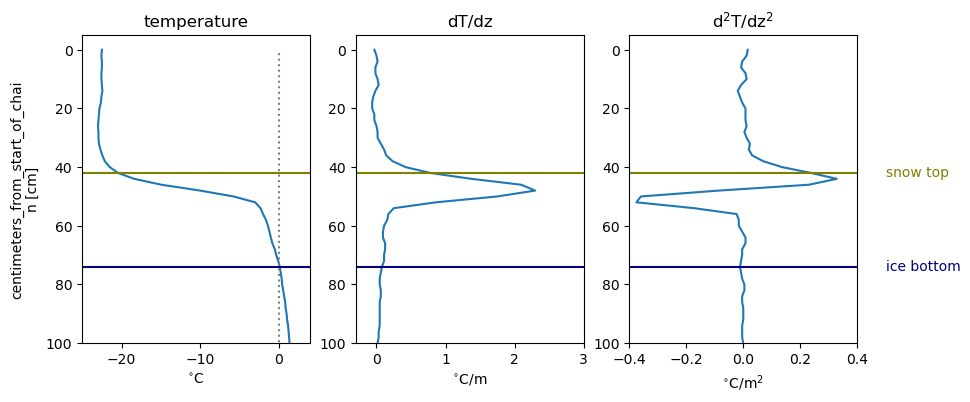

In [115]:
isnowMid = dTdz.where(((da.pos < iceBot) & (da.temp <= 0)), other=0).argmax(dim="pos")
snowMid = da.pos[isnowMid].where(isnowMid != 0, other=da.pos.isel(pos=isurf).values)

isnowTop = xr.where(((da.pos < snowMid) & (dTdz < (0.33 * dTdz.max("pos"))) & (da.temp <= 0)), True, False)[::-1].cumsum("pos")[::-1].argmin("pos")
snowTop = da.pos[isnowTop].where(isnowTop != 0, other=da.pos.isel(pos=isurf).values)

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False)
ax[0].hlines(da.pos.isel(pos=iiceBot), l0, u0, color="navy", ls="-")
ax[0].hlines(da.pos.isel(pos=isnowTop), l0, u0, color="olive", ls="-")
ax[0].vlines(0, 300, 0, ls=":", color="gray")
ax[0].set_xlim(l0, u0)
ax[0].set_title("temperature")
ax[0].set_xlabel("$^{\circ}$C")

dTdz.plot(ax=ax[1], y="pos", yincrease=False)
ax[1].hlines(da.pos.isel(pos=iiceBot), l1, u1, color="navy", ls="-")
ax[1].hlines(da.pos.isel(pos=isnowTop), l1, u1, color="olive", ls="-")
ax[1].set_xlim(l1, u1)
ax[1].set_title("dT/dz")
ax[1].set_xlabel("$^{\circ}$C/m")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False)
ax[2].hlines(da.pos.isel(pos=iiceBot), l2, u2, color="navy", ls="-")
ax[2].text(u2 + 0.1, da.pos.isel(pos=iiceBot), "ice bottom", va="center", ha="left", color="navy")
ax[2].hlines(da.pos.isel(pos=isnowTop), l2, u2, color="olive", ls="-")
ax[2].text(u2 + 0.1, da.pos.isel(pos=isnowTop), "snow top", va="center", ha="left", color="olive")
ax[2].set_xlim(l2, u2)
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("$^{\circ}$C/m$^{2}$")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")
for axx in [ax[0], ax[1], ax[2]]:
    axx.set_ylim(100, -5)

The snow/ice interface can either be considered the bottom of the snow pack or the top of the ice. The methods to detect either of the two differ but in most cases result in the same interface, except for after warm air temperatures or flooding when snow is transformed to ice. During this transformation period from snow to snow-ice, the detection based on the bottom of the snow pack tends to detect (snow-)ice earlier, while the detection based on the top of the ice considers the (re-)frozen snow as snow for longer before detecting it as (snow-)ice. This is all based on anecdotal evidence and testing would be required to validate these statements.  

To detect the bottom of the snow, we go down from the location *somwehere* in the snow pack and find where the second derivative of temperature (which is negative where we are looking) drops below half its minimum value: $\frac{d^{2}T}{dz^{2}} < \frac{1}{2}\,min(\frac{d^{2}T}{dz^{2}})$.  

Two steps are necessary to detect the top of the ice. First, we detect the maximum $\frac{dT}{dz}$ at or below the depth of the bottom of the snow detected before. Second, we find the minimum of  $\frac{d^{2}T}{dz^{2}}$ at or below this maximum of $\frac{dT}{dz}$.

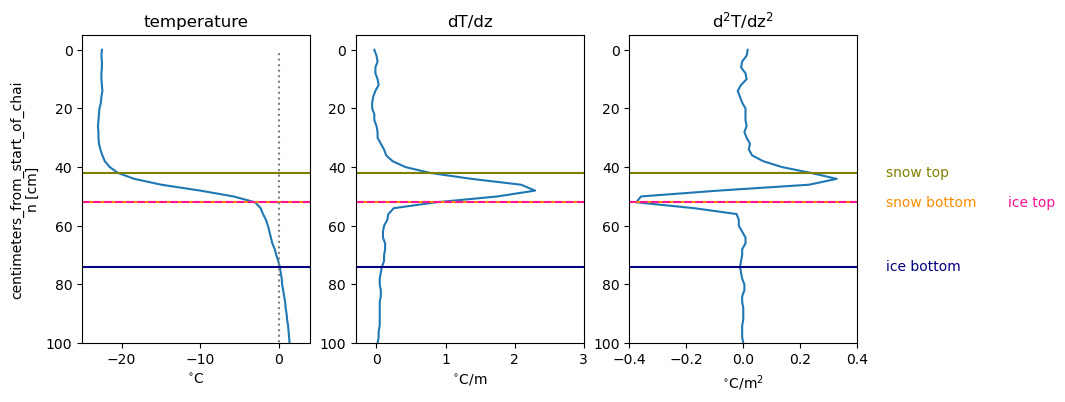

In [116]:
isnowBot = xr.where(((da.pos >= snowMid) & (da.pos <= iceBot) & (da.temp <= 0) & (d2Tdz2 < (0.5 * d2Tdz2.min("pos")))), True, False).cumsum("pos").argmax("pos")
snowBot = da.pos[isnowBot].where(isnowBot != 0, other=da.pos.isel(pos=isurf).values)

iiceTop1st = dTdz.where(((da.pos >= snowBot) & (da.temp <= 0)), other=0).argmax(dim="pos")
iceTop1st = da.pos[iiceTop1st].where(iiceTop1st != 0, other=da.pos.isel(pos=isurf).values)

iiceTop = d2Tdz2.where(((da.pos >= iceTop1st) & (da.temp <= 0) & (da.pos <= iceBot)), other=0).argmin(dim="pos")
iceTop = da.pos[iiceTop].where(iiceTop != 0, other=da.pos.isel(pos=isurf).values)

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False)
ax[0].hlines(da.pos.isel(pos=iiceBot), l0, u0, color="navy", ls="-")
ax[0].hlines(da.pos.isel(pos=isnowTop), l0, u0, color="olive", ls="-")
ax[0].hlines(da.pos.isel(pos=isnowBot), l0, u0, color="darkorange", ls="-")
ax[0].hlines(da.pos.isel(pos=iiceTop), l0, u0, color="deeppink", ls="--")
ax[0].vlines(0, 300, 0, ls=":", color="gray")
ax[0].set_xlim(l0, u0)
ax[0].set_title("temperature")
ax[0].set_xlabel("$^{\circ}$C")

dTdz.plot(ax=ax[1], y="pos", yincrease=False)
ax[1].hlines(da.pos.isel(pos=iiceBot), l1, u1, color="navy", ls="-")
ax[1].hlines(da.pos.isel(pos=isnowTop), l1, u1, color="olive", ls="-")
ax[1].hlines(da.pos.isel(pos=isnowBot), l1, u1, color="darkorange", ls="-")
ax[1].hlines(da.pos.isel(pos=iiceTop), l1, u1, color="deeppink", ls="--")
ax[1].set_xlim(l1, u1)
ax[1].set_title("dT/dz")
ax[1].set_xlabel("$^{\circ}$C/m")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False)
ax[2].hlines(da.pos.isel(pos=iiceBot), l2, u2, color="navy", ls="-")
ax[2].text(u2 + 0.1, da.pos.isel(pos=iiceBot), "ice bottom", va="center", ha="left", color="navy")
ax[2].hlines(da.pos.isel(pos=isnowTop), l2, u2, color="olive", ls="-")
ax[2].text(u2 + 0.1, da.pos.isel(pos=isnowTop), "snow top", va="center", ha="left", color="olive")
ax[2].hlines(da.pos.isel(pos=isnowBot), l2, u2, color="darkorange", ls="-")
ax[2].text(u2 + 0.1, da.pos.isel(pos=isnowBot), "snow bottom", va="center", ha="left", color="darkorange")
ax[2].hlines(da.pos.isel(pos=iiceTop), l2, u2, color="deeppink", ls="--")
ax[2].text(u2 + 0.53, da.pos.isel(pos=iiceTop), "ice top", va="center", ha="left", color="deeppink")
ax[2].set_xlim(l2, u2)
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("$^{\circ}$C/m$^{2}$")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")
for axx in [ax[0], ax[1], ax[2]]:
    axx.set_ylim(100, -5)

## Air temperature > 0 $^{\circ}$C

Next a case where air temperature is positive (case 2 in the first figure)  

In this case, the gradients are much smaller and especially any singals in $\frac{d^{2}T}{dz^{2}}$ are hardly larger than the noise level.

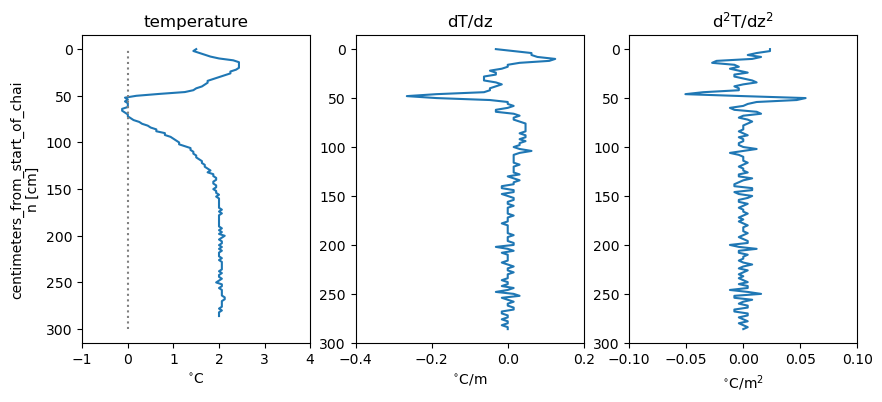

In [117]:
d = d2
da = data.isel(time=d, pos=slice(None, -1))

dTdz = da.temp.differentiate("pos")
d2Tdz2 = dTdz.differentiate("pos")

l0 = -1
u0 = 4
l1 = -0.4
u1 = 0.2
l2 = -0.1
u2 = 0.1

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False)
ax[0].vlines(0, 300, 0, ls=":", color="gray")
ax[0].set_xlim(l0, u0)
ax[0].set_title("temperature")
ax[0].set_xlabel("$^{\circ}$C")

dTdz.plot(ax=ax[1], y="pos", yincrease=False)
ax[1].set_xlim(l1, u1)
ax[1].set_title("dT/dz")
ax[1].set_xlabel("$^{\circ}$C/m")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False)
ax[2].set_xlim(l2, u2)
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("$^{\circ}$C/m$^{2}$")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")

Detection of the bottom of the ice is the same, independent of atmospheric temperature.

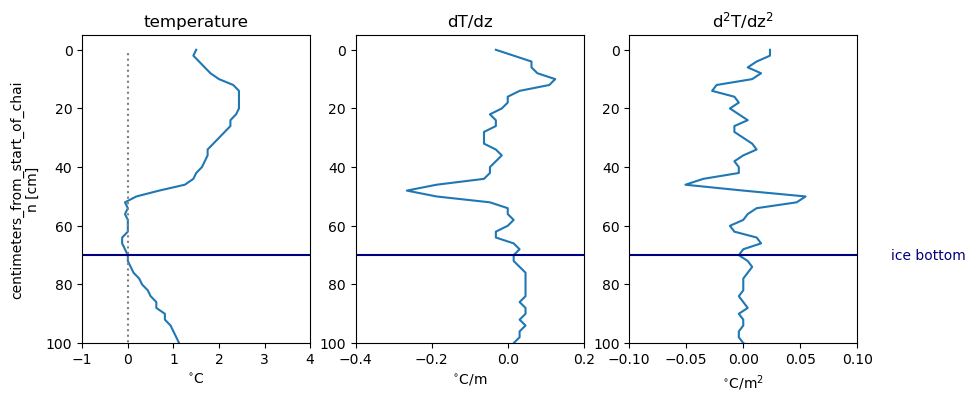

In [118]:
iiceBot = xr.where(da.temp < 0, True, False)[::-1].cumsum("pos")[::-1].argmin("pos") 
iceBot = da.pos[iiceBot].where(((iiceBot != 0) & (iiceBot >= isurf)), other=da.pos.isel(pos=isurf).values)

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False)
ax[0].hlines(da.pos.isel(pos=iiceBot), l0, u0, color="navy", ls="-")
ax[0].vlines(0, 300, 0, ls=":", color="gray")
ax[0].set_xlim(l0, u0)
ax[0].set_title("temperature")
ax[0].set_xlabel("$^{\circ}$C")

dTdz.plot(ax=ax[1], y="pos", yincrease=False)
ax[1].hlines(da.pos.isel(pos=iiceBot), l1, u1, color="navy", ls="-")
ax[1].set_xlim(l1, u1)
ax[1].set_title("dT/dz")
ax[1].set_xlabel("$^{\circ}$C/m")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False)
ax[2].hlines(da.pos.isel(pos=iiceBot), l2, u2, color="navy", ls="-")
ax[2].text(u2 + 0.03, da.pos.isel(pos=iiceBot), "ice bottom", va="center", ha="left", color="navy")
ax[2].set_xlim(l2, u2)
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("$^{\circ}$C/m$^{2}$")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")
for axx in [ax[0], ax[1], ax[2]]:
    axx.set_ylim(100, -5)

As the temperature gradients between air and snow are simply inverted to the case before, we invert our criteria. We now look for the minimum in $\frac{dT}{dz}$ and the point where $\frac{dT}{dz}$ becomes larger than 1/3 of its minimum above: $\frac{dT}{dz} > \frac{1}{3}\,min(\frac{dT}{dz})$

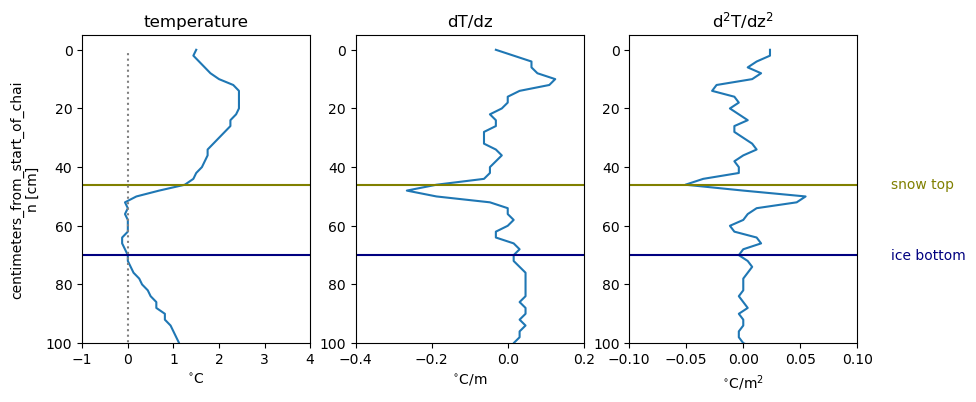

In [119]:
isnowMid = dTdz.where(((da.pos < iceBot)), other=0).argmin(dim="pos")
snowMid = da.pos[isnowMid].where(isnowMid != 0, other=da.pos.isel(pos=isurf).values)
isnowTop = xr.where(((da.pos < snowMid) & (dTdz > (0.33 * dTdz.min("pos")))), True, False)[::-1].cumsum("pos")[::-1].argmin("pos")
snowTop = da.pos[isnowTop].where(isnowTop != 0, other=da.pos.isel(pos=isurf).values)

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False)
ax[0].hlines(da.pos.isel(pos=iiceBot), l0, u0, color="navy", ls="-")
ax[0].hlines(da.pos.isel(pos=isnowTop), l0, u0, color="olive", ls="-")
ax[0].vlines(0, 300, 0, ls=":", color="gray")
ax[0].set_xlim(l0, u0)
ax[0].set_title("temperature")
ax[0].set_xlabel("$^{\circ}$C")

dTdz.plot(ax=ax[1], y="pos", yincrease=False)
ax[1].hlines(da.pos.isel(pos=iiceBot), l1, u1, color="navy", ls="-")
ax[1].hlines(da.pos.isel(pos=isnowTop), l1, u1, color="olive", ls="-")
ax[1].set_xlim(l1, u1)
ax[1].set_title("dT/dz")
ax[1].set_xlabel("$^{\circ}$C/m")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False)
ax[2].hlines(da.pos.isel(pos=iiceBot), l2, u2, color="navy", ls="-")
ax[2].text(u2 + 0.03, da.pos.isel(pos=iiceBot), "ice bottom", va="center", ha="left", color="navy")
ax[2].hlines(da.pos.isel(pos=isnowTop), l2, u2, color="olive", ls="-")
ax[2].text(u2 + 0.03, da.pos.isel(pos=isnowTop), "snow top", va="center", ha="left", color="olive")
ax[2].set_xlim(l2, u2)
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("$^{\circ}$C/m$^{2}$")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")
for axx in [ax[0], ax[1], ax[2]]:
    axx.set_ylim(100, -5)

The detection of the ice/snow interface when atmospheric temperatures are near or above zero is very sensitive to thresholds and noise due to the small gradients. In principle, as before, we just look for minima instead of maxima, and maxima instead of minima etc.

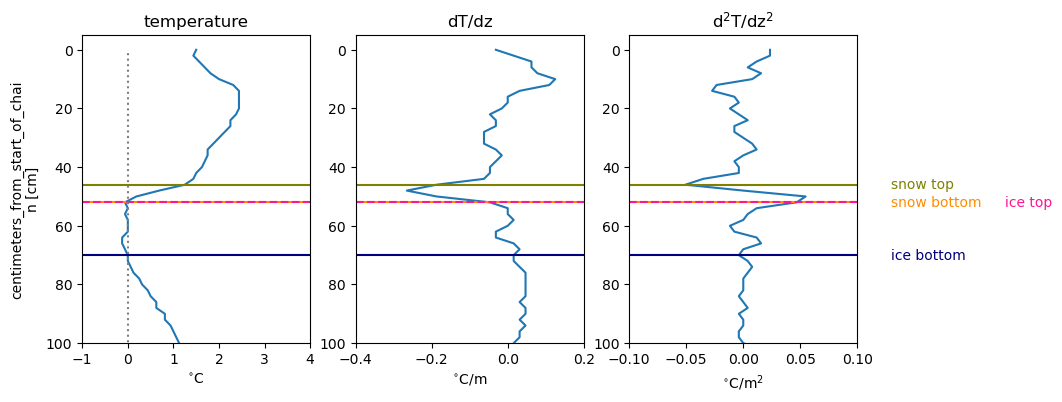

In [120]:
isnowBot = xr.where(((da.pos >= snowMid) & (da.pos <= iceBot) & (d2Tdz2 > (0.5 * d2Tdz2.max("pos")))), True, False).cumsum("pos").argmax("pos")
snowBot = da.pos[isnowBot].where(isnowBot != 0, other=da.pos.isel(pos=isurf).values)
iiceTop1st = dTdz.where(((da.pos >= snowBot) & (da.temp <= 0)), other=0).argmin(dim="pos")
iceTop1st = da.pos[iiceTop1st].where(iiceTop1st != 0, other=da.pos.isel(pos=isurf).values)
iiceTop = d2Tdz2.where(((da.pos >= iceTop1st) & (da.temp <= 0)), other=0).argmax(dim="pos")
iceTop = da.pos[iiceTop].where(iiceTop != 0, other=da.pos.isel(pos=isurf).values)

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False)
ax[0].hlines(da.pos.isel(pos=iiceBot), l0, u0, color="navy", ls="-")
ax[0].hlines(da.pos.isel(pos=isnowTop), l0, u0, color="olive", ls="-")
ax[0].hlines(da.pos.isel(pos=isnowBot), l0, u0, color="darkorange", ls="-")
ax[0].hlines(da.pos.isel(pos=iiceTop), l0, u0, color="deeppink", ls="--")
ax[0].vlines(0, 300, 0, ls=":", color="gray")
ax[0].set_xlim(l0, u0)
ax[0].set_title("temperature")
ax[0].set_xlabel("$^{\circ}$C")

dTdz.plot(ax=ax[1], y="pos", yincrease=False)
ax[1].hlines(da.pos.isel(pos=iiceBot), l1, u1, color="navy", ls="-")
ax[1].hlines(da.pos.isel(pos=isnowTop), l1, u1, color="olive", ls="-")
ax[1].hlines(da.pos.isel(pos=isnowBot), l1, u1, color="darkorange", ls="-")
ax[1].hlines(da.pos.isel(pos=iiceTop), l1, u1, color="deeppink", ls="--")
ax[1].set_xlim(l1, u1)
ax[1].set_title("dT/dz")
ax[1].set_xlabel("$^{\circ}$C/m")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False)
ax[2].hlines(da.pos.isel(pos=iiceBot), l2, u2, color="navy", ls="-")
ax[2].text(u2 + 0.03, da.pos.isel(pos=iiceBot), "ice bottom", va="center", ha="left", color="navy")
ax[2].hlines(da.pos.isel(pos=isnowTop), l2, u2, color="olive", ls="-")
ax[2].text(u2 + 0.03, da.pos.isel(pos=isnowTop), "snow top", va="center", ha="left", color="olive")
ax[2].hlines(da.pos.isel(pos=isnowBot), l2, u2, color="darkorange", ls="-")
ax[2].text(u2 + 0.03, da.pos.isel(pos=isnowBot), "snow bottom", va="center", ha="left", color="darkorange")
ax[2].hlines(da.pos.isel(pos=iiceTop), l2, u2, color="deeppink", ls="--")
ax[2].text(u2 + 0.13, da.pos.isel(pos=iiceTop), "ice top", va="center", ha="left", color="deeppink")
ax[2].set_xlim(l2, u2)
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("$^{\circ}$C/m$^{2}$")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")
for axx in [ax[0], ax[1], ax[2]]:
    axx.set_ylim(100, -5)

## Detection on time series

To account for the difficulties encountered when air temperatures are around or above 0$^{\circ}$C, there are some measures that we take when working with time series of data.  

As seen below, there is a lot of noiese in the detections during the warmer period.

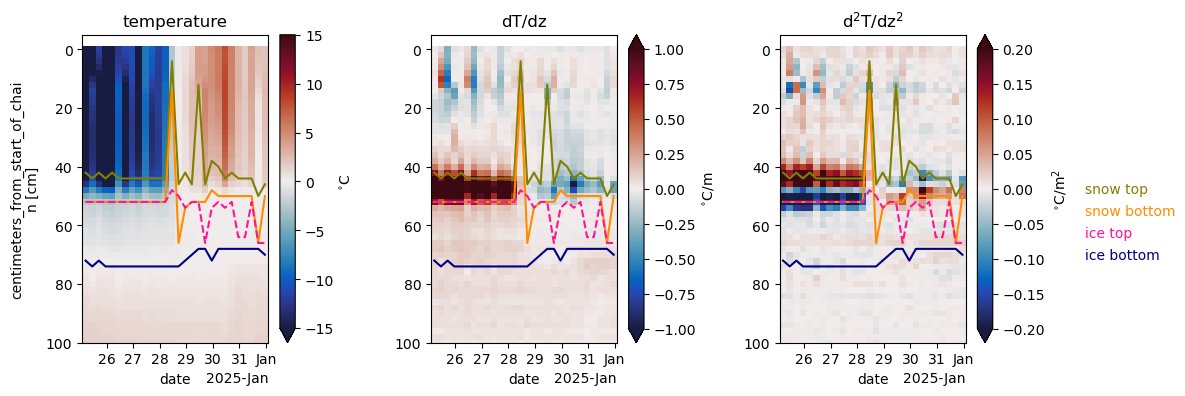

In [167]:
# Create boolean, True when air temperature is > 0
t_air_gt_0 = (data.temp.isel(pos=-1) >= 0).compute()
da = data.isel(pos=slice(None, -1))
# Get first and second vertical derivative
dTdz = da.temp.differentiate("pos")
d2Tdz2 = dTdz.differentiate("pos")
# find bottom of the box where the thermistor string exits (this is a minimum in dTdz somewhere within the first meter of the string)
# we just assume its value here for this example
ibox = 2
# ice-water interface (bottom of the ice)
iiceBot = xr.where(da.temp < 0, True, False)[:, ::-1].cumsum("pos")[:, ::-1].argmin("pos")
iceBot = da.pos[iiceBot].where(((iiceBot != 0) & (iiceBot >= isurf)), other=da.pos.isel(pos=isurf).values)
# the maximum of the first derivative is located in the snow
isnowMid = dTdz.where(((da.pos < iceBot) & (da.temp <= 0)), other=0).argmax(dim="pos")
snowMid = da.pos[isnowMid].where(isnowMid != 0, other=da.pos.isel(pos=isurf).values)
# the top of the snow
isnowTop = xr.where(((da.pos < snowMid)
                     & (dTdz < (0.33 * dTdz.max("pos"))) & (da.temp <= 0)), True, False)[::-1, :].cumsum("pos")[::-1, :].argmin("pos")
snowTop = da.pos[isnowTop].where(isnowTop != 0, other=da.pos.isel(pos=isurf).values)
# the bottom of the snow
isnowBot = xr.where(((da.pos >= snowMid) & (da.pos <= iceBot) & (da.temp <= 0)
                     & (d2Tdz2 < (0.5 * d2Tdz2.min("pos")))), True, False).cumsum("pos").argmax("pos")
snowBot = da.pos[isnowBot].where(isnowBot != 0, other=da.pos.isel(pos=isurf).values)
# for the ice top, first find the maximum first derivative below the snow bottom
iiceTop1st = dTdz.where(((da.pos >= snowBot) & (da.temp <= 0)), other=0).argmax(dim="pos")
iceTop1st = da.pos[iiceTop1st].where(iiceTop1st != 0, other=da.pos.isel(pos=isurf).values)
# ice top (in most cases snow bottom == ice top)
iiceTop = d2Tdz2.where(((da.pos >= iceTop1st) & (da.temp <= 0) & (da.pos <= iceBot)), other=0).argmin(dim="pos")
iceTop = da.pos[iiceTop].where(iiceTop != 0, other=da.pos.isel(pos=isurf).values)
# redo for air temperatures >= 0 
isnowMid[t_air_gt_0] = dTdz.where(((da.pos < iceBot)), other=0).argmin(dim="pos")[t_air_gt_0]
snowMid = da.pos[isnowMid].where(isnowMid != 0, other=da.pos.isel(pos=isurf).values)
isnowTop[t_air_gt_0] = xr.where(((da.pos < snowMid)
                                 & (dTdz > (0.33 * dTdz.min("pos")))), True, False)[::-1, :].cumsum("pos")[::-1, :].argmin("pos")[t_air_gt_0]
snowTop = da.pos[isnowTop].where(isnowTop != 0, other=da.pos.isel(pos=isurf).values)
isnowBot[t_air_gt_0] = xr.where(((da.pos >= snowMid) & (da.pos <= iceBot)
                                 & (d2Tdz2 > (0.5 * d2Tdz2.max("pos")))), True, False).cumsum("pos").argmax("pos")[t_air_gt_0]
snowBot = da.pos[isnowBot].where(isnowBot != 0, other=da.pos.isel(pos=isurf).values)
iiceTop1st[t_air_gt_0]  = dTdz.where(((da.pos >= snowBot) & (da.temp <= 0)), other=0).argmin(dim="pos")[t_air_gt_0]
iceTop1st = da.pos[iiceTop1st].where(iiceTop1st != 0, other=da.pos.isel(pos=isurf).values)
iiceTop[t_air_gt_0]  = d2Tdz2.where(((da.pos >= iceTop1st) & (da.temp <= 0)), other=0).argmax(dim="pos")[t_air_gt_0]
iceTop = da.pos[iiceTop].where(iiceTop != 0, other=da.pos.isel(pos=isurf).values)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False, cmap=cmo.balance, vmin=-15, vmax=15, cbar_kwargs={"label": "$^{\circ}$C"})
iceBot.plot(ax=ax[0], color="navy")
snowTop.plot(ax=ax[0], color="olive")
snowBot.plot(ax=ax[0], color="darkorange")
iceTop.plot(ax=ax[0], color="deeppink", ls="--")
ax[0].set_title("temperature")
ax[0].set_xlabel("date")

dTdz.plot(ax=ax[1], y="pos", yincrease=False, cmap=cmo.balance, vmin=-1, vmax=1, cbar_kwargs={"label": "$^{\circ}$C/m"})
iceBot.plot(ax=ax[1], color="navy")
snowTop.plot(ax=ax[1], color="olive")
snowBot.plot(ax=ax[1], color="darkorange")
iceTop.plot(ax=ax[1], color="deeppink", ls="--")
ax[1].set_title("dT/dz")
ax[1].set_xlabel("date")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False, cmap=cmo.balance, vmin=-0.2, vmax=0.2, cbar_kwargs={"label": "$^{\circ}$C/m$^{2}$"})
iceBot.plot(ax=ax[2], color="navy")
snowTop.plot(ax=ax[2], color="olive")
snowBot.plot(ax=ax[2], color="darkorange")
iceTop.plot(ax=ax[2], color="deeppink", ls="--")
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("date")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")
for axx in [ax[0], ax[1], ax[2]]:
    axx.set_ylim(100, -5)

ax[2].text(da.time.isel(time=-1)+int(4e14), 70, "ice bottom", va="center", ha="left", color="navy")
ax[2].text(da.time.isel(time=-1)+int(4e14), 47.5, "snow top", va="center", ha="left", color="olive")
ax[2].text(da.time.isel(time=-1)+int(4e14), 55, "snow bottom", va="center", ha="left", color="darkorange")
ax[2].text(da.time.isel(time=-1)+int(4e14), 62.5, "ice top", va="center", ha="left", color="deeppink")

plt.subplots_adjust(wspace=0.5)

As a first measure, we look for jumps in the top of the ice from one day to the next and if they esceed a certain threshold, we replace the erroneous value with the value from the day before. The threshold here is chosen to illustrate the method but probably too small for a real application.

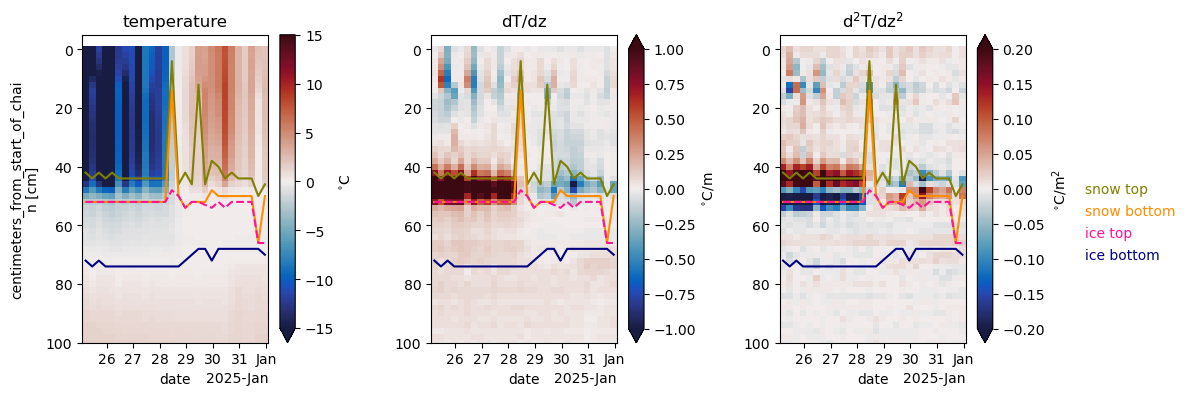

In [168]:
ddticeTop = np.zeros(len(iceTop))
ddticeTop[1::] = iceTop.values[1::] - iceTop.values[0:-1]
t = 1
dice = 10
while t < len(iceTop):
    if np.abs(ddticeTop[t]) > dice:
        if t == len(iceTop) - 1:
            iceTop[t] = iceTop[t-1]
            t += 1
        else:
            tt = t
            while ((iceTop[tt] > iceTop[t-1] + dice) | (iceTop[tt] < iceTop[t-1] - dice)):
                if tt < len(iceTop) - 2:
                    tt += 1
                else:
                    break
            iceTop[t:tt] = np.interp(np.arange(t, tt), [t-1, tt], [iceTop[t-1].values, iceTop[tt].values])
            t = tt + 1
    else:
        t += 1

# redo snow bottom and top after corrections to ice top (they cannot be below ice top)
snowTop[(snowTop > iceTop).compute()] = iceTop[(snowTop > iceTop).compute()]
snowBot[(snowBot > iceTop).compute()] = iceTop[(snowBot > iceTop).compute()]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False, cmap=cmo.balance, vmin=-15, vmax=15, cbar_kwargs={"label": "$^{\circ}$C"})
iceBot.plot(ax=ax[0], color="navy")
snowTop.plot(ax=ax[0], color="olive")
snowBot.plot(ax=ax[0], color="darkorange")
iceTop.plot(ax=ax[0], color="deeppink", ls="--")
ax[0].set_title("temperature")
ax[0].set_xlabel("date")

dTdz.plot(ax=ax[1], y="pos", yincrease=False, cmap=cmo.balance, vmin=-1, vmax=1, cbar_kwargs={"label": "$^{\circ}$C/m"})
iceBot.plot(ax=ax[1], color="navy")
snowTop.plot(ax=ax[1], color="olive")
snowBot.plot(ax=ax[1], color="darkorange")
iceTop.plot(ax=ax[1], color="deeppink", ls="--")
ax[1].set_title("dT/dz")
ax[1].set_xlabel("date")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False, cmap=cmo.balance, vmin=-0.2, vmax=0.2, cbar_kwargs={"label": "$^{\circ}$C/m$^{2}$"})
iceBot.plot(ax=ax[2], color="navy")
snowTop.plot(ax=ax[2], color="olive")
snowBot.plot(ax=ax[2], color="darkorange")
iceTop.plot(ax=ax[2], color="deeppink", ls="--")
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("date")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")
for axx in [ax[0], ax[1], ax[2]]:
    axx.set_ylim(100, -5)

ax[2].text(da.time.isel(time=-1)+int(4e14), 70, "ice bottom", va="center", ha="left", color="navy")
ax[2].text(da.time.isel(time=-1)+int(4e14), 47.5, "snow top", va="center", ha="left", color="olive")
ax[2].text(da.time.isel(time=-1)+int(4e14), 55, "snow bottom", va="center", ha="left", color="darkorange")
ax[2].text(da.time.isel(time=-1)+int(4e14), 62.5, "ice top", va="center", ha="left", color="deeppink")

plt.subplots_adjust(wspace=0.5)

Next, we replace values during days when the largest $|\frac{dT}{dz}|$ is below a certain threshold with values from the day before. This is done because we know that the algorithm does not work for those days with air temperature close to 0$^{\circ}$C.

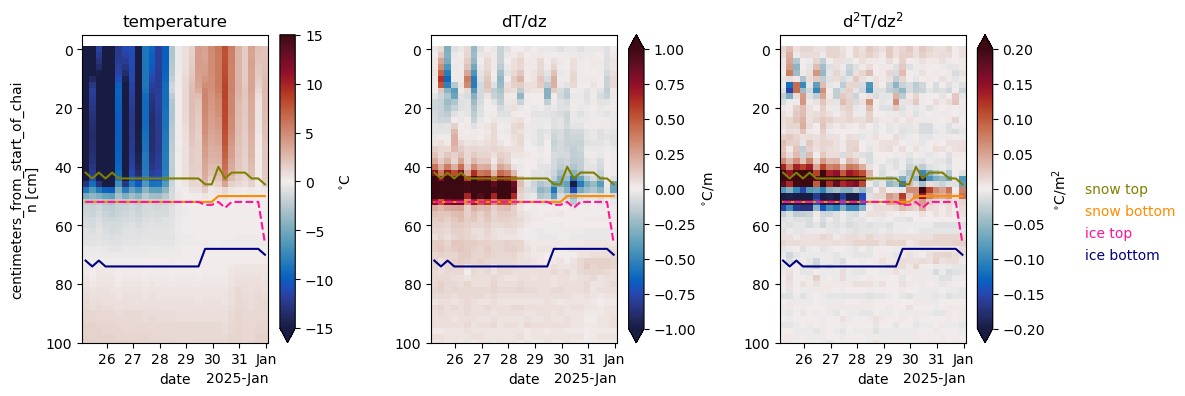

In [169]:
# use values of day before when dTdz is too small
for t in range(1, len(dTdz.time)):
    if not (np.abs(dTdz.isel(time=t, pos=slice(ibox+2, -2))) > 0.33).any().values:
        isnowTop[t] = isnowTop[t-1]
        isnowMid[t] = isnowMid[t-1]
        isnowBot[t] = isnowBot[t-1]
        iiceTop[t] = iiceTop[t-1]
        iiceBot[t] = iiceBot[t-1]
        snowTop[t] = snowTop[t-1]
        snowMid[t] = snowMid[t-1]
        snowBot[t] = snowBot[t-1]
        iceTop[t] = iceTop[t-1]
        iceBot[t] = iceBot[t-1]


fig, ax = plt.subplots(1, 3, figsize=(12, 4))

da.temp.plot(ax=ax[0], y="pos", yincrease=False, cmap=cmo.balance, vmin=-15, vmax=15, cbar_kwargs={"label": "$^{\circ}$C"})
iceBot.plot(ax=ax[0], color="navy")
snowTop.plot(ax=ax[0], color="olive")
snowBot.plot(ax=ax[0], color="darkorange")
iceTop.plot(ax=ax[0], color="deeppink", ls="--")
ax[0].set_title("temperature")
ax[0].set_xlabel("date")

dTdz.plot(ax=ax[1], y="pos", yincrease=False, cmap=cmo.balance, vmin=-1, vmax=1, cbar_kwargs={"label": "$^{\circ}$C/m"})
iceBot.plot(ax=ax[1], color="navy")
snowTop.plot(ax=ax[1], color="olive")
snowBot.plot(ax=ax[1], color="darkorange")
iceTop.plot(ax=ax[1], color="deeppink", ls="--")
ax[1].set_title("dT/dz")
ax[1].set_xlabel("date")

d2Tdz2.plot(ax=ax[2], y="pos", yincrease=False, cmap=cmo.balance, vmin=-0.2, vmax=0.2, cbar_kwargs={"label": "$^{\circ}$C/m$^{2}$"})
iceBot.plot(ax=ax[2], color="navy")
snowTop.plot(ax=ax[2], color="olive")
snowBot.plot(ax=ax[2], color="darkorange")
iceTop.plot(ax=ax[2], color="deeppink", ls="--")
ax[2].set_title("d$^{2}$T/dz$^{2}$")
ax[2].set_xlabel("date")

for axx in [ax[1], ax[2]]:
    axx.set_ylabel("")
for axx in [ax[0], ax[1], ax[2]]:
    axx.set_ylim(100, -5)

ax[2].text(da.time.isel(time=-1)+int(4e14), 70, "ice bottom", va="center", ha="left", color="navy")
ax[2].text(da.time.isel(time=-1)+int(4e14), 47.5, "snow top", va="center", ha="left", color="olive")
ax[2].text(da.time.isel(time=-1)+int(4e14), 55, "snow bottom", va="center", ha="left", color="darkorange")
ax[2].text(da.time.isel(time=-1)+int(4e14), 62.5, "ice top", va="center", ha="left", color="deeppink")

plt.subplots_adjust(wspace=0.5)

The procedures illustrated above removed most of the spurious spikes in the detected interfaces. 